C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Eva\AppData\Roaming\Python\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:


Linear Mixed Effects Analysis Results:

rewarded_trial_1:
----------------------------------------
                   0        1                    2         3
0             Model:  MixedLM  Dependent Variable:    weight
1  No. Observations:       32              Method:      REML
2        No. Groups:        5               Scale:    0.1443
3   Min. group size:        4      Log-Likelihood:  -16.3005
4   Max. group size:        8           Converged:       Yes
5   Mean group size:      6.4                               

Random Effects:
            Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept   0.412    0.095   4.334  0.000   0.226  0.599
condition  -0.157    0.134  -1.170  0.242  -0.420  0.106
Group Var   0.000    0.063                              
Raw p-value: 0.2422
FDR-corrected p-value: 0.7242

rewarded_trial_2:
----------------------------------------
                   0        1                    2         3
0             Model:  MixedLM  Dependent Variable:    wei

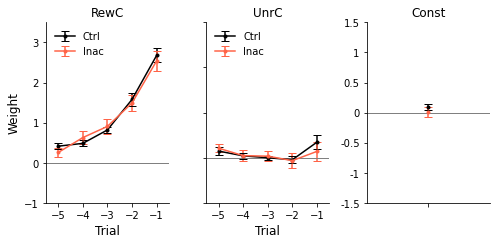


Sum of Absolute Weights Analysis:
                   0        1                    2                3
0             Model:  MixedLM  Dependent Variable:  sum_abs_weights
1  No. Observations:       32              Method:             REML
2        No. Groups:        5               Scale:           1.4070
3   Min. group size:        4      Log-Likelihood:         -54.0851
4   Max. group size:        8           Converged:              Yes
5   Mean group size:      6.4                                      

Random Effects:
           Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept  6.143    0.569  10.793  0.000   5.028  7.259
condition  0.060    0.419   0.142  0.887  -0.762  0.882
mouse Var  1.164    0.906                              


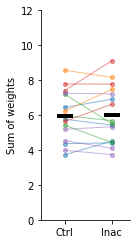

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import BD_SciAdv as BD
from os.path import join as pjoin
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection

# Set up plotting parameters
plt.rcParams['svg.fonttype'] = 'none'
plt_colors = BD.plt_color_dir()

def load_weights(server_dir):
    weights_data = pd.read_pickle(pjoin(server_dir, 'opto_summary_pkl_files/PPC_Long_1000iter.pkl'))
    return weights_data

def prepare_lme_data(weights_data, trial_pos):
    # Get weights and session info
    weights = weights_data['weights']  # shape: (n_sessions, n_weights)
    session_info = weights_data['session_info']
    
    # Create lists to store data
    all_weights = []
    all_conditions = []  # 1 for opto, 0 for control
    all_mice = []
    all_sessions = []
    
    # Process each session
    for i, session in enumerate(session_info):
        mouse = session['mouse']
        date = session['date']
        session_id = f"{mouse}_{date}"
        
        # Get weights for this session
        session_weights = weights[i]
        
        # Control condition
        all_weights.append(session_weights[trial_pos])
        all_conditions.append(0)
        all_mice.append(mouse)
        all_sessions.append(session_id)
        
        # Opto condition
        all_weights.append(session_weights[trial_pos + 10])
        all_conditions.append(1)
        all_mice.append(mouse)
        all_sessions.append(session_id)
    
    # Create DataFrame
    df = pd.DataFrame({
        'weight': all_weights,
        'condition': all_conditions,
        'mouse': all_mice,
        'session': all_sessions
    })
    
    return df

def run_lme_analysis(df):
    formula = 'weight ~ condition'
    groups = df['mouse']
    model = MixedLM.from_formula(
        formula=formula,
        data=df,
        groups=groups,
        re_formula='1'
    )
    
    start_params = np.array([0.0, 0.0, 0.1]) 
    
    try:
        # First try with default method
        result = model.fit(start_params=start_params)
    except:
        try:
            # Try with L-BFGS-B
            result = model.fit(method='lbfgsb', start_params=start_params)
        except:
            # Finally try with Newton-Raphson
            result = model.fit(method='nm', start_params=start_params)
    
    return result


def analyze_all_trials(weights_data):
    results = {}
    
    # Collect p-values for FDR correction
    rewarded_pvals = []
    unrewarded_pvals = []
    
    # Analyze rewarded trials
    for trial in range(5):
        df = prepare_lme_data(weights_data, trial)
        result = run_lme_analysis(df)
        pval = result.pvalues['condition']
        rewarded_pvals.append(pval)
        results[f'rewarded_trial_{trial+1}'] = {
            'result': result,
            'data': df,
            'raw_pval': pval
        }
    
    # Analyze unrewarded trials
    for trial in range(5):
        df = prepare_lme_data(weights_data, trial + 5)
        result = run_lme_analysis(df)
        pval = result.pvalues['condition']
        unrewarded_pvals.append(pval)
        results[f'unrewarded_trial_{trial+1}'] = {
            'result': result,
            'data': df,
            'raw_pval': pval
        }
    
    # Apply FDR correction separately for rewarded and unrewarded trials
    _, rewarded_corrected_pvals = fdrcorrection(rewarded_pvals)
    _, unrewarded_corrected_pvals = fdrcorrection(unrewarded_pvals)
    
    # Add corrected p-values to results
    for i in range(5):
        results[f'rewarded_trial_{i+1}']['corrected_pval'] = rewarded_corrected_pvals[i]
        results[f'unrewarded_trial_{i+1}']['corrected_pval'] = unrewarded_corrected_pvals[i]
    
    return results

def print_lme_results(results):
    print("\nLinear Mixed Effects Analysis Results:")
    print("=" * 80)
    
    for trial_name, trial_data in results.items():
        print(f"\n{trial_name}:")
        print("-" * 40)
        print(trial_data['result'].summary().tables[0])  # Print fixed effects
        print("\nRandom Effects:")
        print(trial_data['result'].summary().tables[1])  # Print random effects
        print(f"Raw p-value: {trial_data['raw_pval']:.4f}")
        print(f"FDR-corrected p-value: {trial_data['corrected_pval']:.4f}")
        print("=" * 80)

def plot_opto_weights(weights_data, results, save_path=None):
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, sharey=False, sharex=False, figsize=[7, 3.5], tight_layout=False)
    
    # Get mean and sem weights
    mean_vec = weights_data['mean_weights']
    sem_vec = weights_data['sem_weights']
    
    # Plot weights for rewarded and unrewarded conditions
    n_back = 5
    x_plt = -np.linspace((n_back), 1, n_back)
    
    # Define indices for plotting
    r_ru5_ctrl_inds = slice(0,5)
    u_ru5_ctrl_inds = slice(5,10)
    r_ru5_opto_inds = slice(10,15)
    u_ru5_opto_inds = slice(15,20)
    
    # Function to get significance marker
    def get_sig_marker(p_value):
        if p_value < 0.001:
            return '***'
        elif p_value < 0.01:
            return '**'
        elif p_value < 0.05:
            return '*'
        return ''
    
    # Plot rewarded condition
    axes[0].plot([-11, 0], [0, 0], c='grey', linewidth=1)
    axes[0].errorbar(x_plt, mean_vec[r_ru5_ctrl_inds], sem_vec[r_ru5_ctrl_inds],
                    c='k', marker='o', markersize=3, linestyle='-', capsize=4, 
                    label='Ctrl')
    axes[0].errorbar(x_plt, mean_vec[r_ru5_opto_inds], sem_vec[r_ru5_opto_inds],
                    c='tomato', marker='o', markersize=3, linestyle='-', 
                    capsize=4, label='Inac')
    
    # Add significance markers for rewarded trials using FDR-corrected p-values
    for i in range(5):
        p_value = results[f'rewarded_trial_{i+1}']['corrected_pval']
        sig_marker = get_sig_marker(p_value)
        if sig_marker:
            y_max = max(mean_vec[i], mean_vec[i+10]) + max(sem_vec[i], sem_vec[i+10]) + 0.2
            axes[0].text(x_plt[i], y_max, sig_marker, ha='center', va='bottom')
    
    axes[0].set_xticks(x_plt)
    axes[0].set_xlim([-5.5, -0.5])
    axes[0].set_ylim([-1, 3.5])
    y_ticks = [-1.0, 0, 1.0, 2.0, 3]
    axes[0].set_yticks(y_ticks)
    axes[0].set_title('RewC', fontsize=12)
    axes[0].set_ylabel('Weight', fontsize=12)
    axes[0].set_xlabel('Trial', fontsize=12)
    axes[0].legend(loc='upper left', frameon=False)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    
    # Plot unrewarded condition
    axes[1].plot([-11, 0], [0, 0], c='grey', linewidth=1)
    axes[1].errorbar(x_plt, mean_vec[u_ru5_ctrl_inds], sem_vec[u_ru5_ctrl_inds],
                    c='k', marker='o', markersize=3, linestyle='-', capsize=4, 
                    label='Ctrl')
    axes[1].errorbar(x_plt, mean_vec[u_ru5_opto_inds], sem_vec[u_ru5_opto_inds],
                    c='tomato', marker='o', markersize=3, linestyle='-', 
                    capsize=4, label='Inac')
    
    # Add significance markers for unrewarded trials using FDR-corrected p-values
    for i in range(5):
        p_value = results[f'unrewarded_trial_{i+1}']['corrected_pval']
        sig_marker = get_sig_marker(p_value)
        if sig_marker:
            y_max = max(mean_vec[i+5], mean_vec[i+15]) + max(sem_vec[i+5], sem_vec[i+15]) + 0.2
            axes[1].text(x_plt[i], y_max, sig_marker, ha='center', va='bottom')
    
    axes[1].set_xticks(x_plt)
    axes[1].set_xlim([-5.5, -0.5])
    axes[1].set_yticks(y_ticks)
    axes[1].set_yticklabels([''] * len(y_ticks))
    axes[1].set_title('UnrC', fontsize=12)
    axes[1].set_xlabel('Trial', fontsize=12)
    axes[1].legend(loc='upper left', frameon=False)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    
    # Plot constant term
    axes[2].plot([-11, 0], [0, 0], c='grey', linewidth=1)
    axes[2].errorbar(-5, mean_vec[-1], sem_vec[-1],
                    c='k', marker='o', markersize=3, linestyle='-', capsize=4)
    axes[2].errorbar(-5, mean_vec[-2], sem_vec[-2],
                    c='tomato', marker='o', markersize=3, linestyle='-', capsize=4)
    axes[2].set_title('Const')
    axes[2].set_xticks([-5])
    axes[2].set_xticklabels([''])
    axes[2].set_xlim([-6, -4])
    axes[2].set_yticks([-1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
    axes[2].set_yticklabels(['-1.5', '-1', '-0.5', '0', '0.5', '1', '1.5'])
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        # Save as SVG
        if save_path.endswith('.svg'):
            plt.savefig(save_path, format="svg", dpi=300, bbox_inches='tight')
        # Save as PNG
        elif save_path.endswith('.png'):
            plt.savefig(save_path, format="png", dpi=300, bbox_inches='tight')
    
    return fig

def analyze_sum_abs_weights(weights_data):
    """Calculate and analyze the sum of absolute weights for rewarded choice history"""
    # Get weights and session info
    weights = weights_data['weights']  # shape: (n_sessions, n_weights)
    session_info = weights_data['session_info']
    
    # Create lists to store data
    all_sums = []
    all_conditions = []  # 1 for opto, 0 for control
    all_mice = []
    all_sessions = []
    
    # Process each session
    for i, session in enumerate(session_info):
        mouse = session['mouse']
        date = session['date']
        session_id = f"{mouse}_{date}"
        
        # Get weights for this session
        session_weights = weights[i]
        
        # Calculate sum of absolute weights for control condition (first 5 weights)
        ctrl_sum = np.sum(np.abs(session_weights[:5]))
        all_sums.append(ctrl_sum)
        all_conditions.append(0)
        all_mice.append(mouse)
        all_sessions.append(session_id)
        
        # Calculate sum of absolute weights for opto condition (weights 10-14)
        opto_sum = np.sum(np.abs(session_weights[10:15]))
        all_sums.append(opto_sum)
        all_conditions.append(1)
        all_mice.append(mouse)
        all_sessions.append(session_id)
    
    # Create DataFrame
    df = pd.DataFrame({
        'sum_abs_weights': all_sums,
        'condition': all_conditions,
        'mouse': all_mice,
        'session': all_sessions
    })
    
    return df

def plot_sum_abs_weights(df, save_path=None):
    """Plot the sum of absolute weights comparison between control and inactivation"""
    fig = plt.figure(figsize=(2, 3.5))
    
    # Calculate mean for each condition
    ctrl_data = df[df['condition'] == 0]['sum_abs_weights']
    opto_data = df[df['condition'] == 1]['sum_abs_weights']
    
    ctrl_mean = ctrl_data.mean()
    opto_mean = opto_data.mean()
    
    # Get unique mice and assign colors
    unique_mice = df['mouse'].unique()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    mouse_colors = {mouse: colors[i % len(colors)] for i, mouse in enumerate(unique_mice)}
    
    # Plot individual points with lines connecting paired samples from each session
    for session in df['session'].unique():
        session_data = df[df['session'] == session]
        mouse = session_data['mouse'].iloc[0]
        ctrl_val = session_data[session_data['condition'] == 0]['sum_abs_weights'].values[0]
        opto_val = session_data[session_data['condition'] == 1]['sum_abs_weights'].values[0]
        plt.plot([0.2, 1], [ctrl_val, opto_val], 'o-', 
                alpha=0.5, linewidth=1, markersize=4,
                color=mouse_colors[mouse])
    
    # Add mean lines
    plt.plot([0.1, 0.3], [ctrl_mean, ctrl_mean], 'k-', linewidth=4)
    plt.plot([0.9, 1.1], [opto_mean, opto_mean], 'k-', linewidth=4)
    
    # Customize plot
    plt.xticks([0.2, 1], ['Ctrl', 'Inac'])
    plt.xlim([-0.2,1.3])
    plt.ylim([0,12])
#     plt.xlabel('RSC Short')
    plt.ylabel('Sum of weights')
    
    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    # Add significance marker
    # Run LME analysis
    model = MixedLM.from_formula(
        formula='sum_abs_weights ~ condition',
        data=df,
        groups='mouse',
        re_formula='1'
    )
    
    try:
        result = model.fit()
        p_value = result.pvalues['condition']
        
        # Function to get significance marker
        def get_sig_marker(p_value):
            if p_value < 0.001:
                return '***'
            elif p_value < 0.01:
                return '**'
            elif p_value < 0.05:
                return '*'
            return ''
        
        sig_marker = get_sig_marker(p_value)
        if sig_marker:
            y_max = max(df['sum_abs_weights']) + 0.5
            plt.text(0.6, y_max, sig_marker, ha='center', va='bottom', fontsize=12)
    except:
        print("Failed to add significance marker")
    
    plt.tight_layout()
    
    if save_path:
        # Save as SVG
        if save_path.endswith('.svg'):
            plt.savefig(save_path, format="svg", dpi=300, bbox_inches='tight')
        # Save as PNG
        elif save_path.endswith('.png'):
            plt.savefig(save_path, format="png", dpi=300, bbox_inches='tight')
    
    return fig

def main():
    # Set the server directory
    server_dir = "Z:\\People\\Eva\\bpod_processed_data_opto"  # Replace with your data directory
    
    # Load the preprocessed weights
    weights_data = load_weights(server_dir)
    
    # Run LME analysis for each trial position
    results = analyze_all_trials(weights_data)
    
    # Print results
    print_lme_results(results)
    
    # Plot the weights with significance markers
    fig1 = plot_opto_weights(weights_data, results, save_path=pjoin(server_dir, 'opto_summary_figures\\PPC_Long_1000iter.svg'))
    plt.show(fig1)
    
    # Analyze and plot sum of absolute weights
    df_sum = analyze_sum_abs_weights(weights_data)
    
    # Run LME analysis for sum of absolute weights
    model = MixedLM.from_formula(
        formula='sum_abs_weights ~ condition',
        data=df_sum,
        groups='mouse',
        re_formula='1'
    )
    
    # Fit the model
    try:
        result = model.fit()
        print("\nSum of Absolute Weights Analysis:")
        print("=" * 80)
        print(result.summary().tables[0])
        print("\nRandom Effects:")
        print(result.summary().tables[1])
    except:
        print("Failed to fit mixed effects model for sum of absolute weights")
    
    # Plot the sum of absolute weights
    fig2 = plot_sum_abs_weights(df_sum, save_path=pjoin(server_dir, 'opto_summary_figures\\PPC_Long_1000iter_sum_of_weight.svg'))
    plt.show(fig2)

if __name__ == "__main__":
    main()

